<a href="https://colab.research.google.com/github/usmanumer038/ml-internship-work/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

**Lane:** Refresh / Content Opportunity Scoring

This notebook turns the validated model output into a practical content review queue.

The model score is used for **directional decision-support**. It helps prioritize which content items should be reviewed first. It does not automatically refresh, edit, publish, delete, or change content.

The playbook uses observed March signals and the validated Random Forest model to create ranked actions with simple reason codes.


## Setup

This notebook recreates the validated Week-5/Week-6 feature pipeline. The final queue is generated from observed March data.

The queue contains pseudonymized IDs only and is intended for internal human review.


In [4]:
!pip -q install duckdb scikit-learn pandas matplotlib

import os
import json
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

BASE = "hf://datasets/FlyRank/internship-warehouse"
TABLE = f"{BASE}/fact_content_daily_performance/**/*.parquet"

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

print("Connected to FlyRank Internship Warehouse")


Connected to FlyRank Internship Warehouse


# 1. Ranked actions + reason codes

The queue ranks content items by the model's measured probability of a later decline.

A score does not automatically mean that content should be changed. It only determines review priority.

### Action levels

- **High priority review** — high model score and a clear review reason.
- **Standard review** — moderate score or a mixed signal.
- **Monitor** — lower score; no immediate content action is recommended.

Reason codes are simple explanations based on observed March signals. They are not causal explanations.


In [5]:
# March features are used for the action queue.
# April is used only to evaluate the validation model.

march_query = f'''
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    SUM(ga4_sessions) AS sessions,
    SUM(ga4_engaged_sessions) AS engaged_sessions
FROM read_parquet('{TABLE}', hive_partitioning=1)
WHERE month = '2026-03'
  AND gsc_data_available IS TRUE
  AND ga4_data_available IS TRUE
  AND ga4_sessions > 0
GROUP BY 1, 2
'''

queue_df = con.sql(march_query).df()

queue_df["engagement_rate"] = (
    queue_df["engaged_sessions"] / queue_df["sessions"]
).clip(0, 1)

features = [
    "impressions",
    "clicks",
    "sessions",
    "engaged_sessions",
    "engagement_rate"
]

print("Content items available for ranking:", len(queue_df))
display(queue_df.head())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content items available for ranking: 63650


,client_hash_id,content_hash_id,impressions,clicks,sessions,engaged_sessions,engagement_rate
0,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,458.0,2.0,14.0,0.0,0.000000
1,client_65de48885f4ef01b,content_e25ea7297a1dffd3,3943.0,23.0,54.0,1.0,0.018519
2,client_65de48885f4ef01b,content_3c286ded8bd68120,2180.0,15.0,30.0,2.0,0.066667
3,client_65de48885f4ef01b,content_b2108e8fe3360fa6,503.0,8.0,23.0,1.0,0.043478
4,client_65de48885f4ef01b,content_ff867882e604fa96,24.0,0.0,2.0,0.0,0.000000


### Train the validated model

The model is trained using March features and a later April decline outcome.

The grouped-by-client validation design is checked first. After validation, the same model settings are fitted on the available labeled data to generate the operational review queue.

This is a practical ranking workflow, not a production deployment.


In [6]:
validation_query = f'''
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_engaged_sessions) AS engaged_sessions
    FROM read_parquet('{TABLE}', hive_partitioning=1)
    WHERE month = '2026-03'
      AND gsc_data_available IS TRUE
      AND ga4_data_available IS TRUE
      AND ga4_sessions > 0
    GROUP BY 1, 2
),
april AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(ga4_sessions) AS april_sessions
    FROM read_parquet('{TABLE}', hive_partitioning=1)
    WHERE month = '2026-04'
      AND ga4_data_available IS TRUE
    GROUP BY 1, 2
)
SELECT
    m.client_hash_id,
    m.content_hash_id,
    m.impressions,
    m.clicks,
    m.sessions,
    m.engaged_sessions,
    COALESCE(a.april_sessions, 0) AS april_sessions
FROM march m
LEFT JOIN april a
    ON m.client_hash_id = a.client_hash_id
   AND m.content_hash_id = a.content_hash_id
'''

validation_df = con.sql(validation_query).df()

validation_df["engagement_rate"] = (
    validation_df["engaged_sessions"] / validation_df["sessions"]
).clip(0, 1)

validation_df["target_decline"] = (
    validation_df["april_sessions"] < validation_df["sessions"]
).astype(int)

X = validation_df[features]
y = validation_df["target_decline"]
groups = validation_df["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

validation_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

validation_model.fit(X_train, y_train)

validation_prob = validation_model.predict_proba(X_test)[:, 1]
grouped_auc = roc_auc_score(y_test, validation_prob)

print("Grouped validation ROC-AUC:", round(grouped_auc, 3))
print(
    "Client overlap:",
    len(set(groups.iloc[train_idx]).intersection(set(groups.iloc[test_idx])))
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Grouped validation ROC-AUC: 0.793
Client overlap: 0


In [7]:
# Fit the same validated model configuration on all available labeled rows
# to generate the ranked March content review queue.

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    validation_df[features],
    validation_df["target_decline"]
)

queue_df["model_score"] = (
    final_model.predict_proba(queue_df[features])[:, 1]
)

# Create simple observed reason codes.
impression_threshold = queue_df["impressions"].quantile(0.75)
low_engagement_threshold = queue_df["engagement_rate"].quantile(0.25)
session_threshold = queue_df["sessions"].quantile(0.75)

def build_reason(row):
    reasons = []

    if row["impressions"] >= impression_threshold:
        reasons.append("High search visibility")

    if row["engagement_rate"] <= low_engagement_threshold:
        reasons.append("Low engagement rate")

    if row["sessions"] >= session_threshold:
        reasons.append("High current traffic")

    if not reasons:
        reasons.append("Model score indicates review priority")

    return "; ".join(reasons[:2])

queue_df["reason_code"] = queue_df.apply(build_reason, axis=1)

def choose_action(score):
    if score >= 0.70:
        return "High priority review"
    elif score >= 0.50:
        return "Standard review"
    return "Monitor"

queue_df["recommended_action"] = queue_df["model_score"].apply(choose_action)

ranked_queue = queue_df.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

ranked_queue["rank"] = ranked_queue.index + 1

queue_columns = [
    "rank",
    "content_hash_id",
    "model_score",
    "recommended_action",
    "reason_code",
    "impressions",
    "clicks",
    "sessions",
    "engagement_rate"
]

display(ranked_queue[queue_columns].head(20))


,rank,content_hash_id,model_score,recommended_action,reason_code,impressions,clicks,sessions,engagement_rate
0,1,content_b023a72383c05c87,0.980693,High priority review,High search visibility; High current traffic,1512.0,1.0,241.0,0.004149
1,2,content_7bead710b3839213,0.980514,High priority review,High search visibility; High current traffic,1421.0,0.0,204.0,0.004902
2,3,content_3415425374b18b14,0.980164,High priority review,High search visibility; High current traffic,1583.0,0.0,129.0,0.007752
3,4,content_21ec4578aeef71ef,0.979686,High priority review,High search visibility; High current traffic,1336.0,0.0,452.0,0.002212
4,5,content_bcbab4e25c25ac52,0.979668,High priority review,High search visibility; High current traffic,703.0,1.0,185.0,0.005405
5,6,content_0262ad57029b3b4a,0.979607,High priority review,High search visibility; High current traffic,2050.0,0.0,254.0,0.003937
6,7,content_94418c2b50e69a03,0.979571,High priority review,High search visibility; High current traffic,1523.0,1.0,100.0,0.010000
7,8,content_05be4b02633ddd1f,0.979414,High priority review,High search visibility; High current traffic,1668.0,0.0,158.0,0.006329
8,9,content_187175cb820509e8,0.979412,High priority review,High search visibility; High current traffic,1632.0,1.0,355.0,0.002817
9,10,content_42de17efab5e5529,0.979403,High priority review,High search visibility; High current traffic,1258.0,0.0,114.0,0.008772


### Archetype → action mapping

The model score is only one part of the playbook. The observed signal pattern provides an archetype that helps a reviewer decide what to inspect first.

| Archetype | Observed pattern | Suggested human action |
|---|---|---|
| High visibility, low engagement | High impressions and low engagement | Review relevance, search intent, structure, and content usefulness |
| High traffic, high risk score | High sessions and high model score | Prioritize review because the item may affect more observed traffic |
| High model score, mixed signals | No single clear observed reason | Review manually before choosing an action |
| Lower model score | Lower immediate measured risk | Monitor rather than immediately changing content |

These mappings are decision-support rules. They do not prove why performance may change.


In [8]:
def assign_archetype(row):
    if (
        row["impressions"] >= impression_threshold and
        row["engagement_rate"] <= low_engagement_threshold
    ):
        return "High visibility, low engagement"

    if (
        row["sessions"] >= session_threshold and
        row["model_score"] >= 0.70
    ):
        return "High traffic, high risk score"

    if row["model_score"] >= 0.50:
        return "High model score, mixed signals"

    return "Lower model score"

ranked_queue["archetype"] = ranked_queue.apply(
    assign_archetype,
    axis=1
)

archetype_actions = {
    "High visibility, low engagement":
        "Review search intent, relevance, structure, and usefulness",
    "High traffic, high risk score":
        "Prioritize human review because more observed traffic may be affected",
    "High model score, mixed signals":
        "Inspect manually before selecting any content action",
    "Lower model score":
        "Monitor; no immediate content change recommended"
}

ranked_queue["human_review_action"] = (
    ranked_queue["archetype"].map(archetype_actions)
)

display(
    ranked_queue[
        ["rank", "archetype", "recommended_action",
         "reason_code", "human_review_action", "model_score"]
    ].head(20)
)


,rank,archetype,recommended_action,reason_code,human_review_action,model_score
0,1,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.980693
1,2,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.980514
2,3,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.980164
3,4,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979686
4,5,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979668
5,6,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979607
6,7,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979571
7,8,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979414
8,9,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979412
9,10,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979403


### Decay / refresh insight

This playbook treats a possible decline signal as a reason to **inspect content freshness**, not as proof that content has decayed.

A human reviewer can consider whether the content may be outdated, less aligned with current search intent, incomplete, or still performing normally despite the score.

The safe workflow is:

**Model ranking → human review → evidence check → possible refresh decision → later monitoring**

The model does not decide that a page is stale by itself.


# 2. Intended use and limits

### Intended use

The playbook is intended for a content or SEO team that needs a practical way to prioritize a large review queue.

It helps answer:

> Which content items should a human inspect first?

The score is useful for prioritization. The reason codes help the reviewer understand the observed signal pattern.

### Limits

This playbook is not valid for:

- proving that content is outdated,
- proving why traffic may decline,
- proving that a refresh will improve performance,
- automatically publishing content changes,
- making irreversible content decisions without review.

The measured model performance is based on the selected historical period and grouped validation design. Performance may change when client behavior, search behavior, or data patterns change.


In [9]:
action_summary = (
    ranked_queue["recommended_action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="items")
)

archetype_summary = (
    ranked_queue["archetype"]
    .value_counts()
    .rename_axis("archetype")
    .reset_index(name="items")
)

print("Action queue summary:")
display(action_summary)

print("Archetype summary:")
display(archetype_summary)


Action queue summary:


,action,items
0,Monitor,40088
1,High priority review,12564
2,Standard review,10998


Archetype summary:


,archetype,items
0,Lower model score,34899
1,"High model score, mixed signals",12335
2,"High traffic, high risk score",8287
3,"High visibility, low engagement",8129


### Cost / value thinking

The queue should not be treated as a list where every item receives the same amount of work.

A practical review order considers:

- **Value:** How much observed traffic or visibility may be involved?
- **Risk:** How high is the directional model score?
- **Cost:** How much human effort is required to inspect and potentially refresh the content?

A high-score item with very little observed traffic may not always be the first item worth expensive work. Likewise, a high-traffic item may deserve review even when the recommended action is not automatic.

The model supports prioritization; people make the final cost/value decision.


In [10]:
# A simple decision-support priority value.
# This is not a causal estimate of business value.

max_sessions = ranked_queue["sessions"].max()

ranked_queue["traffic_weight"] = (
    ranked_queue["sessions"] / max_sessions
).clip(0, 1)

ranked_queue["review_priority_value"] = (
    0.7 * ranked_queue["model_score"] +
    0.3 * ranked_queue["traffic_weight"]
)

ranked_queue["review_priority_value"] = (
    ranked_queue["review_priority_value"].round(4)
)

display(
    ranked_queue[
        [
            "rank",
            "model_score",
            "traffic_weight",
            "review_priority_value",
            "recommended_action"
        ]
    ].head(10)
)


,rank,model_score,traffic_weight,review_priority_value,recommended_action
0,1,0.980693,0.092585,0.7143,High priority review
1,2,0.980514,0.078371,0.7099,High priority review
2,3,0.980164,0.049558,0.7010,High priority review
3,4,0.979686,0.173646,0.7379,High priority review
4,5,0.979668,0.071072,0.7071,High priority review
5,6,0.979607,0.097580,0.7150,High priority review
6,7,0.979571,0.038417,0.6972,High priority review
7,8,0.979414,0.060699,0.7038,High priority review
8,9,0.979412,0.136381,0.7265,High priority review
9,10,0.979403,0.043796,0.6987,High priority review


# 3. Human review + the no-go list

Every recommended action requires human review.

Before changing content, a reviewer should check:

1. Whether the item is still relevant to its current audience and search intent.
2. Whether there is evidence that the content is outdated or incomplete.
3. Whether recent traffic behavior supports taking action.
4. Whether a change could create SEO, editorial, brand, legal, or user-experience risk.
5. Whether the expected value justifies the review and editing effort.

### What should NOT be automated

The following actions should not be triggered automatically by this model:

- publishing refreshed content,
- rewriting or deleting content,
- changing URLs,
- changing important SEO metadata without review,
- redirecting pages,
- deciding that content is obsolete,
- claiming that a refresh will recover traffic.

The model produces a review priority, not an autonomous content management system.


In [11]:
human_review_rules = pd.DataFrame({
    "Review step": [
        "Check relevance and search intent",
        "Check freshness and completeness",
        "Inspect recent performance context",
        "Check risks of changing content",
        "Approve or reject action"
    ],
    "Automation status": [
        "Human required",
        "Human required",
        "Human required",
        "Human required",
        "Human required"
    ]
})

no_go_list = pd.DataFrame({
    "No-go action": [
        "Automatic publishing",
        "Automatic rewriting",
        "Automatic deletion",
        "Automatic URL changes",
        "Automatic redirects",
        "Automatic causal claims"
    ],
    "Reason": [
        "The model only prioritizes review",
        "Editorial quality requires human judgment",
        "Deletion can create irreversible risk",
        "URL changes can affect SEO and users",
        "Redirects require context and approval",
        "Prediction does not prove causation"
    ]
})

print("Human review rules:")
display(human_review_rules)

print("No-go list:")
display(no_go_list)


Human review rules:


,Review step,Automation status
0,Check relevance and search intent,Human required
1,Check freshness and completeness,Human required
2,Inspect recent performance context,Human required
3,Check risks of changing content,Human required
4,Approve or reject action,Human required


No-go list:


,No-go action,Reason
0,Automatic publishing,The model only prioritizes review
1,Automatic rewriting,Editorial quality requires human judgment
2,Automatic deletion,Deletion can create irreversible risk
3,Automatic URL changes,URL changes can affect SEO and users
4,Automatic redirects,Redirects require context and approval
5,Automatic causal claims,Prediction does not prove causation


# 4. Monitoring / retrain triggers

The recommendations can become stale when traffic patterns, clients, search behavior, or data quality change.

The playbook should be monitored rather than treated as permanently valid.

### Light monitoring checks

- Check whether required data is still available.
- Check whether feature distributions change substantially.
- Check whether the positive decline rate changes.
- Re-measure model performance when later outcomes become available.
- Review whether false positives or false negatives create too much human-review cost.

### Retrain or revalidate when

- important data availability changes,
- feature distributions shift materially,
- measured grouped validation performance drops,
- the decline rate changes substantially,
- the content population changes,
- a meaningful workflow change affects the interpretation of the data.

These are monitoring triggers, not automatic retraining rules.


In [12]:
monitoring_baseline = {
    "model_version": "random_forest_week7_playbook",
    "grouped_validation_roc_auc": round(float(grouped_auc), 4),
    "rows_ranked": int(len(ranked_queue)),
    "march_positive_rate": round(float(validation_df["target_decline"].mean()), 4),
    "median_impressions": round(float(ranked_queue["impressions"].median()), 4),
    "median_sessions": round(float(ranked_queue["sessions"].median()), 4),
    "median_engagement_rate": round(
        float(ranked_queue["engagement_rate"].median()), 4
    )
}

print(json.dumps(monitoring_baseline, indent=2))


{
  "model_version": "random_forest_week7_playbook",
  "grouped_validation_roc_auc": 0.7932,
  "rows_ranked": 63650,
  "march_positive_rate": 0.5239,
  "median_impressions": 106.0,
  "median_sessions": 4.0,
  "median_engagement_rate": 0.0
}


In [13]:
# Save the monitoring baseline as a committed receipt for the paper.

with open(
    "work/outputs/w07_monitoring_baseline.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(monitoring_baseline, f, indent=2)

print("Saved: work/outputs/w07_monitoring_baseline.json")


Saved: work/outputs/w07_monitoring_baseline.json


# 5. Exports for the paper

The ranked queue is exported as CSV so later work can reuse the exact generated recommendation list.

A small summary figure is also saved for the paper.

The CSV is generated by the notebook and may remain out of git according to the repository's leak-guard rules. The notebook itself is the reproducible source for the queue.


In [14]:
# Prepare a public-safe export.
# Keep only pseudonymized identifiers and derived decision-support fields.

export_columns = [
    "rank",
    "content_hash_id",
    "model_score",
    "recommended_action",
    "reason_code",
    "archetype",
    "human_review_action",
    "review_priority_value"
]

export_queue = ranked_queue[export_columns].copy()

export_queue["model_score"] = export_queue["model_score"].round(4)

export_path = "work/outputs/w07_ranked_content_queue.csv"

export_queue.to_csv(
    export_path,
    index=False
)

print("Saved ranked queue:", export_path)
print("Rows exported:", len(export_queue))
display(export_queue.head(20))


Saved ranked queue: work/outputs/w07_ranked_content_queue.csv
Rows exported: 63650


,rank,content_hash_id,model_score,recommended_action,reason_code,archetype,human_review_action,review_priority_value
0,1,content_b023a72383c05c87,0.9807,High priority review,High search visibility; High current traffic,"High traffic, high risk score",Prioritize human review because more observed ...,0.7143
1,2,content_7bead710b3839213,0.9805,High priority review,High search visibility; High current traffic,"High traffic, high risk score",Prioritize human review because more observed ...,0.7099
2,3,content_3415425374b18b14,0.9802,High priority review,High search visibility; High current traffic,"High traffic, high risk score",Prioritize human review because more observed ...,0.7010
3,4,content_21ec4578aeef71ef,0.9797,High priority review,High search visibility; High current traffic,"High traffic, high risk score",Prioritize human review because more observed ...,0.7379
4,5,content_bcbab4e25c25ac52,0.9797,High priority review,High search visibility; High current traffic,"High traffic, high risk score",Prioritize human review because more observed ...,0.7071
5,6,content_0262ad57029b3b4a,0.9796,High priority review,High search visibility; High current traffic,"High traffic, high risk score",Prioritize human review because more observed ...,0.7150
6,7,content_94418c2b50e69a03,0.9796,High priority review,High search visibility; High current traffic,"High traffic, high risk score",Prioritize human review because more observed ...,0.6972
7,8,content_05be4b02633ddd1f,0.9794,High priority review,High search visibility; High current traffic,"High traffic, high risk score",Prioritize human review because more observed ...,0.7038
8,9,content_187175cb820509e8,0.9794,High priority review,High search visibility; High current traffic,"High traffic, high risk score",Prioritize human review because more observed ...,0.7265
9,10,content_42de17efab5e5529,0.9794,High priority review,High search visibility; High current traffic,"High traffic, high risk score",Prioritize human review because more observed ...,0.6987


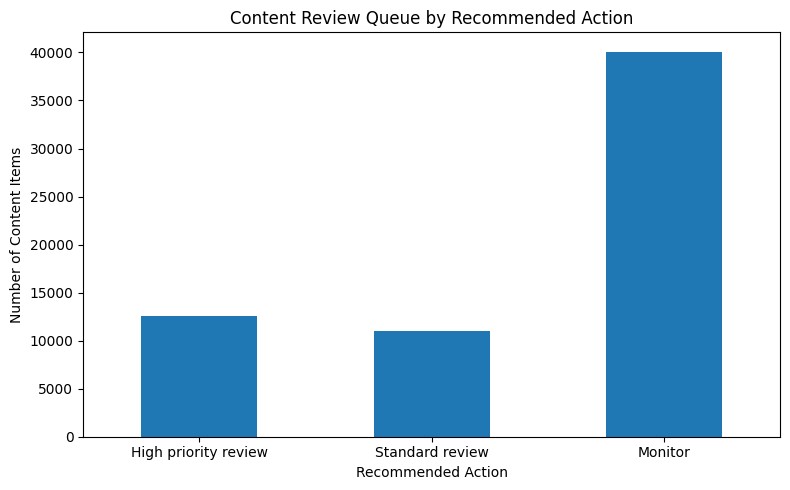

Saved figure: work/figures/w07_action_queue_distribution.png


In [15]:
# Create a reusable figure showing the action queue distribution.

plot_data = (
    ranked_queue["recommended_action"]
    .value_counts()
    .reindex(
        ["High priority review", "Standard review", "Monitor"],
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))
plot_data.plot(kind="bar")
plt.title("Content Review Queue by Recommended Action")
plt.xlabel("Recommended Action")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = "work/figures/w07_action_queue_distribution.png"
plt.savefig(figure_path, dpi=150)
plt.show()

print("Saved figure:", figure_path)


In [16]:
# Save a compact metrics receipt for the paper.

paper_metrics = {
    "week": 7,
    "lane": "Refresh / Content Opportunity Scoring",
    "grouped_validation_roc_auc": round(float(grouped_auc), 4),
    "queue_items": int(len(export_queue)),
    "high_priority_items": int(
        (export_queue["recommended_action"] == "High priority review").sum()
    ),
    "standard_review_items": int(
        (export_queue["recommended_action"] == "Standard review").sum()
    ),
    "monitor_items": int(
        (export_queue["recommended_action"] == "Monitor").sum()
    )
}

with open(
    "work/outputs/w07_action_playbook_metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(paper_metrics, f, indent=2)

print(json.dumps(paper_metrics, indent=2))
print("Saved: work/outputs/w07_action_playbook_metrics.json")


{
  "week": 7,
  "lane": "Refresh / Content Opportunity Scoring",
  "grouped_validation_roc_auc": 0.7932,
  "queue_items": 63650,
  "high_priority_items": 12564,
  "standard_review_items": 10998,
  "monitor_items": 40088
}
Saved: work/outputs/w07_action_playbook_metrics.json


# Self-check

Before submission:

- [x] Ranked actions and reason codes are included.
- [x] Archetype → action mapping is included.
- [x] The possible decay/refresh workflow is explained with safe language.
- [x] Intended use and limits are included.
- [x] Human review rules and a no-go list are included.
- [x] Cost/value thinking is included.
- [x] Monitoring and retrain triggers are included.
- [x] The ranked queue is exported to `work/outputs/`.
- [x] A reusable figure is exported to `work/figures/`.
- [x] Metrics and monitoring receipts are exported as JSON.
- [ ] Run **Runtime → Run all** before committing.
- [ ] Confirm that no client names, URLs, or private queries appear.
- [ ] Commit the notebook as `work/notebooks/w07_action_playbook.ipynb`.

### Final claim

The ranked queue is a **directional decision-support tool for prioritizing human content review**. It does not automatically diagnose content decay, determine the cause of performance changes, or prove that refreshing content will improve performance.
